In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

flname = "c:/users/kiran/Comcast_MachineLearning/Dataset/titanic.csv"

# load the dataset
df = pd.read_csv(flname)

# inspect the dataset
print("df.shape".center(60, "-"))
print(df.shape)

print("df.describe".center(60, "-"))
print(df.describe().round(2).to_string())

print("df.columns".center(60, "-"))
print(df.columns)

print("df.dtypes".center(60, "-"))
print(df.dtypes)

print("df.head".center(60, "-"))
print(df.head(5).to_string())

print("df.value_counts".center(60, "-"))
print(df['Sex'].value_counts())

--------------------------df.shape--------------------------
(891, 12)
------------------------df.describe-------------------------
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33
-------------------------df.columns-------------------------
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
-------------------------df.dtypes--

## MISSING VALUE ANALYSIS

------------Count of null values in each column-------------
---------------------df.isnull().sum()----------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
------------------Missing value percentage------------------
--------------------df.isnull().mean*100--------------------
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64
----------------heat map for missing values-----------------


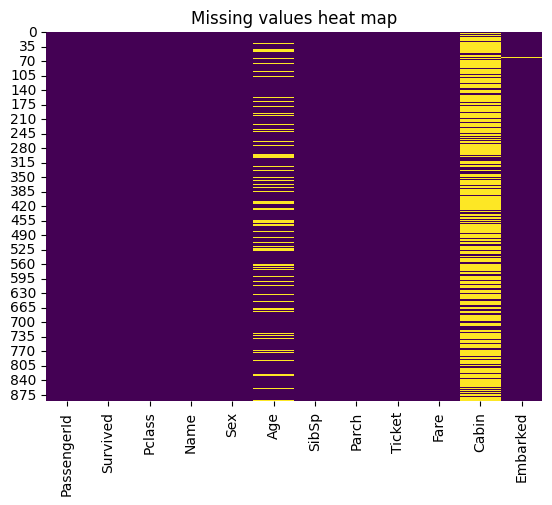

In [2]:
print("Count of null values in each column".center(60, "-"))
print("df.isnull().sum()".center(60, "-"))
print(df.isnull().sum())

print("Missing value percentage".center(60, "-"))
print("df.isnull().mean*100".center(60, "-"))
print(df.isnull().mean() * 100)

print("heat map for missing values".center(60, "-"))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing values heat map")
plt.show()

## Handle Missing Values

In [3]:
# Drop the Cabin Column, too many missing values
df.drop(columns= ['Cabin'], inplace=True)

# impute age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

df1 = df
# impute embarked with mode
# Southampton, Cherboug, Queenstown => S, C, Q
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Sum of Null values in each column".center(60, "-"))
print(df.isnull().sum())

-------------Sum of Null values in each column--------------
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Univariate Analysis

   PassengerId  Survived  Pclass                                                 Name     Sex   Age  SibSp  Parch            Ticket     Fare Embarked
0            1         0       3                              Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0          PC 17599  71.2833        C
2            3         1       3                               Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250        S
3            4         1       1         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000        S
4            5         0       3                             Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500        S


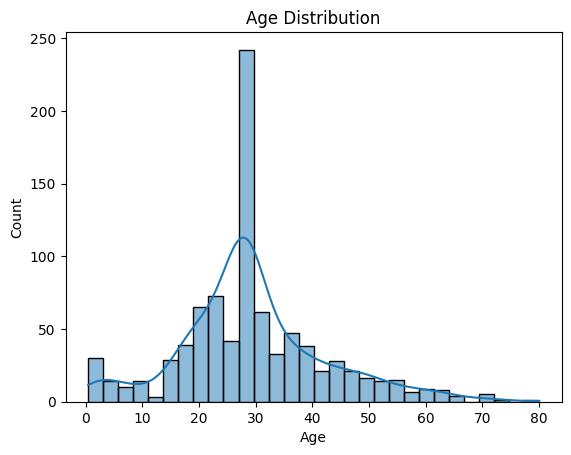

-----------------------Summary of Age-----------------------
Age Summary 
 count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


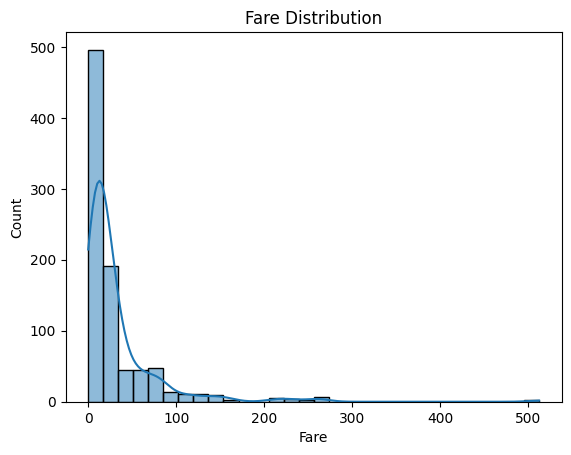

------------------------Fare Summary------------------------
Fare Summary 
 count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


In [4]:
print(df.head(5).to_string())

# Numerical Features
# Age distribution
# KDE - Kernel Density Estimate
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

print("Summary of Age".center(60, "-"))
print("Age Summary \n", df['Age'].describe())

# Fare Distribution
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

print('Fare Summary'.center(60, "-"))
print("Fare Summary \n", df['Fare'].describe())

## Categorical Features

Sex Count 
 Sex
male      577
female    314
Name: count, dtype: int64


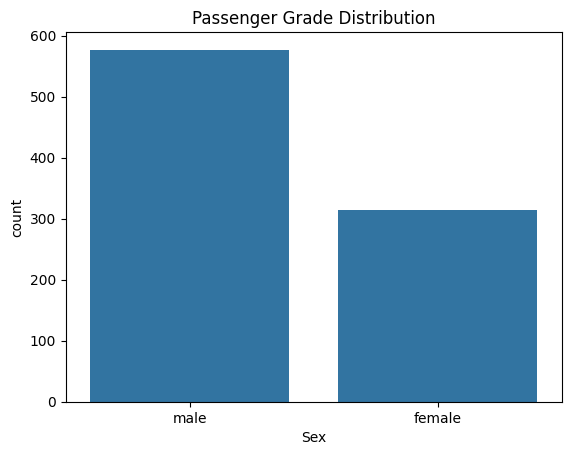

Embarked Counts 
 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


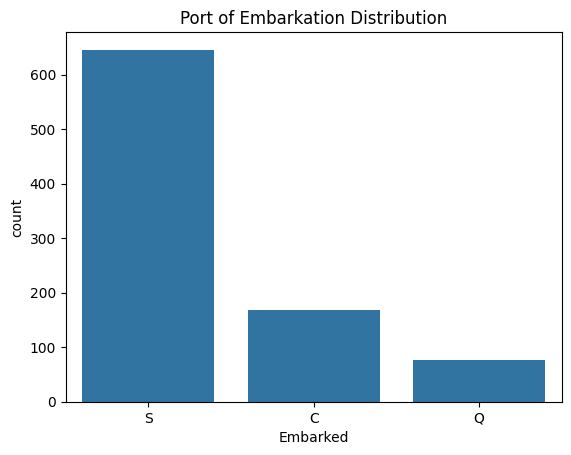

In [5]:
# count of Sex
print("Sex Count \n", df['Sex'].value_counts())
sns.countplot(x = 'Sex', data=df)
plt.title("Passenger Grade Distribution")
plt.show()

# Embarked Count
print("Embarked Counts \n", df['Embarked'].value_counts())
sns.countplot(x='Embarked', data=df)
plt.title("Port of Embarkation Distribution")
plt.show()

## Outlier Detection

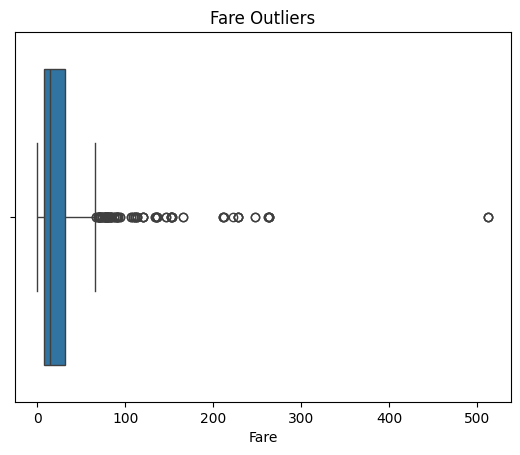

In [6]:
# the box plot show most fares clustered below ~100, but a few extreme values are above 500
sns.boxplot(x=df['Fare'])
plt.title('Fare Outliers')
plt.show()



## corelation analysis

          Survived       Age      Fare     SibSp     Parch
Survived  1.000000 -0.064910  0.257307 -0.035322  0.081629
Age      -0.064910  1.000000  0.096688 -0.233296 -0.172482
Fare      0.257307  0.096688  1.000000  0.159651  0.216225
SibSp    -0.035322 -0.233296  0.159651  1.000000  0.414838
Parch     0.081629 -0.172482  0.216225  0.414838  1.000000


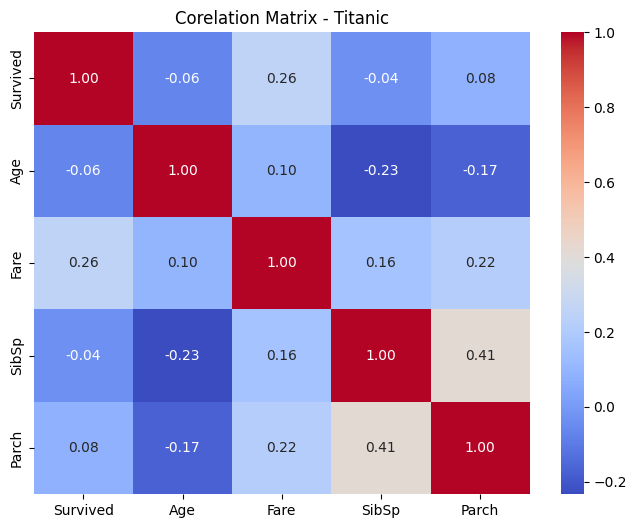

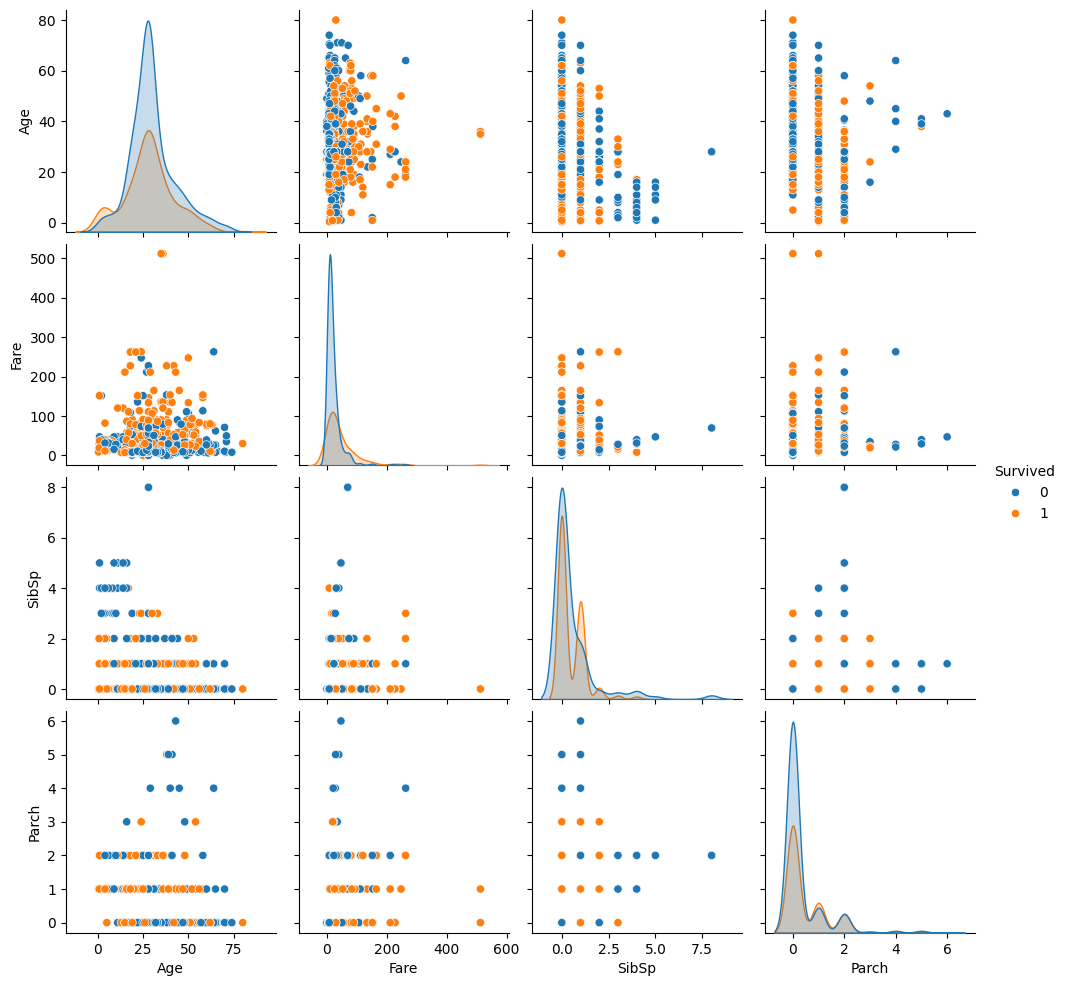

In [7]:
# select the numerical columns, 
# SibSp => siblings and spoused
# Parch => parents and children. solo traveller -> 0, mother with two kid -> 2
# passenger with both parents -> 2

num_cols = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch']

# 1. Corelation Matrix
corr = df[num_cols].corr()
print(corr)

# Heatmapabs
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Corelation Matrix - Titanic")
plt.show()

# PairPlot (optional, for scatter relationship)
sns.pairplot(df[num_cols], hue='Survived')
plt.show()

## Feature Engineering

In [8]:


# 1. Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. IsAlone flag
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 3. Log transform fare
df['Fare_log'] = np.log1p(df['Fare'])

# 4. Encode Categorical Variables
print(df.columns)
df['Sex'] = df['Sex'].map({'male':0, 'female':1})
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')

# 5. Extract title from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].replace(['Lady', 'Countless', 'Capt', 'Col', 'Don', 'Dr.', 
                                   'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'IsAlone',
       'Fare_log'],
      dtype='str')
